# OBI Market Making Strategy Design

基于订单簿失衡（Order Book Imbalance）的做市商策略设计和测试

In [12]:
from numba import njit
from hftbacktest import NONE, NEW, FILLED, CANCELED, EXPIRED, GTC, MARKET
import numpy as np

In [13]:
import numpy as np

from hftbacktest import (
    BacktestAsset,
    ROIVectorMarketDepthBacktest,
    Recorder
)
from hftbacktest.stats import LinearAssetRecord

导入OBI做市商策略模块

In [14]:
import lib.obi_mm as obi_mm

## OBI策略回测测试

In [15]:
# %%time

# 首先检查数据
solusdt_20250630 = np.load('data/output/solusdt_20250630.npz')['data']

# 配置回测资产 - 注意：OBI策略需要ROIVectorMarketDepthBacktest
roi_lb = 100    # ROI下界100tick，订单簿深度计算的价格下限
roi_ub = 200    # ROI上界200tick，订单簿深度计算的价格上限

asset = (
    BacktestAsset()
    .data([solusdt_20250630])
    .initial_snapshot('data/output/solusdt_20250629_eod.npz')
    .linear_asset(1.0)
    .risk_adverse_queue_model()
    .no_partial_fill_exchange()
    .tick_size(00.001)   # SOL价格精度
    .lot_size(0.01)    # SOL最小交易单位
    .trading_value_fee_model(-0.00003, 0.0007)  # Binance费率
    .roi_lb(roi_lb)
    .roi_ub(roi_ub)
)

# 使用ROIVectorMarketDepthBacktest并设置合适的ROI范围
hbt = ROIVectorMarketDepthBacktest([asset])
recorder = Recorder(1, 1_000_000_000)  # 每秒记录一次

print("开始运行OBI策略...")

# 运行OBI做市商策略
_ = obi_mm.obi_mm_strategy(
    hbt, recorder.recorder,
    interval_seconds=0.1,           # 100ms更新频率
    half_spread=80,                 # 半价差80tick
    skew=3.5,                       # 仓位偏度系数
    c1=160,                         # alpha影响系数
    looking_depth=0.025,            # 深度观察范围2.5%
    window_seconds=3600,            # 1小时滑动窗口
    order_qty_dollar=500,            # 单笔订单50美元
    max_position_dollar=2500,       # 最大仓位2500美元
    grid_num=1,                     # 单层网格
    roi_lb=roi_lb,                     # ROI下界
    roi_ub=roi_ub                      # ROI上界
)

print("OBI策略回测完成！")

_ = hbt.close()
recorder.to_npz('stats/obi_mm_solusdt.npz')

开始运行OBI策略...


KeyboardInterrupt: 

## 性能分析和统计

In [5]:
# 加载回测结果并进行分析
data = np.load('stats/obi_mm_solusdt.npz')['0']
stats = (
    LinearAssetRecord(data)
    .resample('5m')  # 按秒重采样
    .stats(book_size=5000)  # 设置账户规模
)

# 显示策略统计摘要
stats.summary()

start,end,SR,Sortino,Return,MaxDrawdown,DailyNumberOfTrades,DailyTurnover,ReturnOverMDD,ReturnOverTrade,MaxPositionValue
datetime[μs],datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2025-06-30 00:00:00,2025-06-30 23:55:00,79.212243,470.918271,5.4328e-7,1.5119e-8,5144.864111,0.000102,35.933018,0.005335,2556.8995


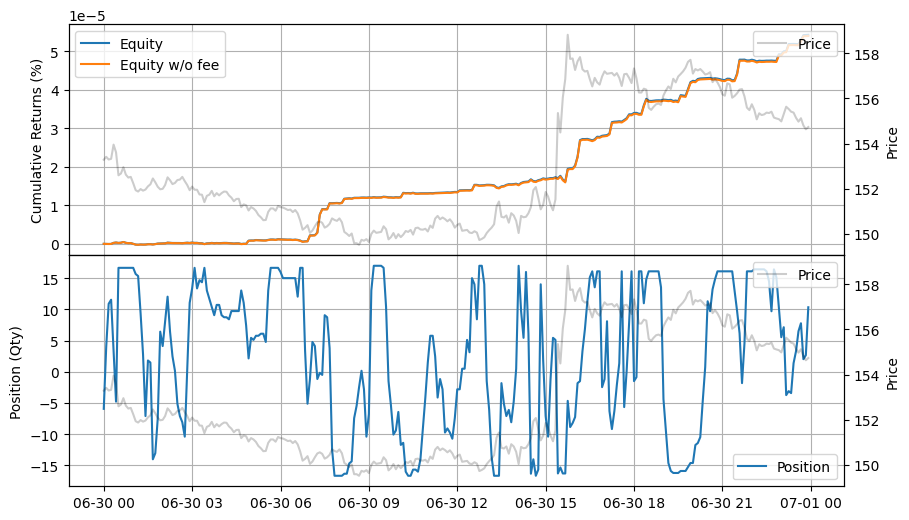

In [6]:
# 绘制策略性能图表
stats.plot()